In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

# Poisson inputs at theta frequency with and without electric field (TI): combining the results from multiple runs

In [2]:
idxs = np.arange(0, 15)

file_labels = {
    "No TI": "no_ti/0",
    "5 Hz": "1000/90_90_5",
    "130 Hz": "1000/90_90_130"
}

output_dir = f"output/temporal-interference/poisson_theta"

colors = {
    "No TI": "steelblue",
    "5 Hz": "lightcoral",
    "130 Hz": "mediumseagreen"
}

## Distribution of firing frequency

In [3]:
spiking_frequencies = {
    "No TI": [pd.read_csv(f"{output_dir}/{idx}/{file_labels['No TI']}/spike_frequency.csv").Frequency.values for idx in idxs],
    "5 Hz": [pd.read_csv(f"{output_dir}/{idx}/{file_labels['5 Hz']}/spike_frequency.csv").Frequency.values for idx in idxs],
    "130 Hz": [pd.read_csv(f"{output_dir}/{idx}/{file_labels['130 Hz']}/spike_frequency.csv").Frequency.values for idx in idxs]
}

spiking_frequencies["No TI"] = np.array(list(itertools.chain.from_iterable(spiking_frequencies["No TI"])))
spiking_frequencies["5 Hz"] = np.array(list(itertools.chain.from_iterable(spiking_frequencies["5 Hz"])))
spiking_frequencies["130 Hz"] = np.array(list(itertools.chain.from_iterable(spiking_frequencies["130 Hz"])))

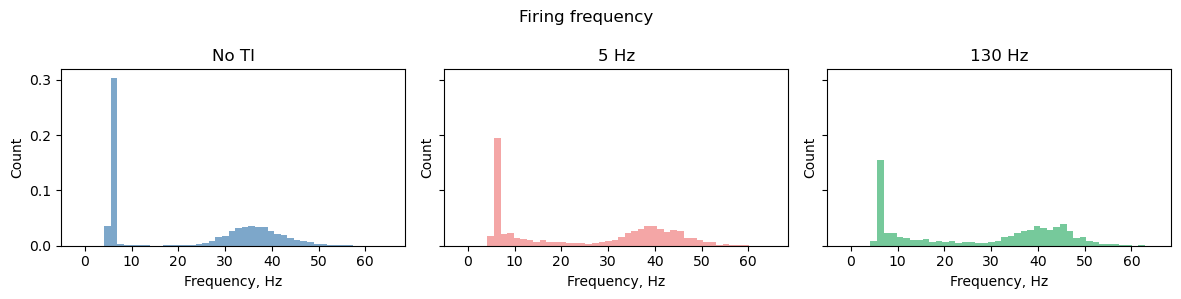

In [4]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3), sharey = True)

max = np.max([spiking_frequencies[key].max() for key in spiking_frequencies.keys()])
min = 0

bin_edges = np.linspace(min, max, num = 50)

for i, label in enumerate(file_labels.keys()):
    spike_frequency = spiking_frequencies[label]
    axs[i].hist(spike_frequency, bins = bin_edges, alpha = 0.7, color = colors[label], density = True)

    axs[i].set_ylabel("Count")
    axs[i].set_xlabel("Frequency, Hz")
    axs[i].set_xlim(-5, max)
    axs[i].set_title(label)

fig.suptitle("Firing frequency")
fig.tight_layout()
plt.show()

## Distribution of interspike intervals

In [5]:
def calculate_isi(spike_frequency):
    spike_times = spike_frequency.Time.values
    np.insert(spike_times, 0, spike_frequency.Time[0] - 1000 / spike_frequency.Frequency[0])

    return np.diff(spike_times)

In [6]:
interspike_intervals = {
    "No TI": [ calculate_isi(pd.read_csv(f"{output_dir}/{idx}/{file_labels['No TI']}/spike_frequency.csv")) for idx in idxs ],
    "5 Hz": [ calculate_isi(pd.read_csv(f"{output_dir}/{idx}/{file_labels['5 Hz']}/spike_frequency.csv")) for idx in idxs ],
    "130 Hz": [ calculate_isi(pd.read_csv(f"{output_dir}/{idx}/{file_labels['130 Hz']}/spike_frequency.csv")) for idx in idxs ]
}

interspike_intervals["No TI"] = np.array(list(itertools.chain.from_iterable(interspike_intervals["No TI"])))
interspike_intervals["5 Hz"] = np.array(list(itertools.chain.from_iterable(interspike_intervals["5 Hz"])))
interspike_intervals["130 Hz"] = np.array(list(itertools.chain.from_iterable(interspike_intervals["130 Hz"])))

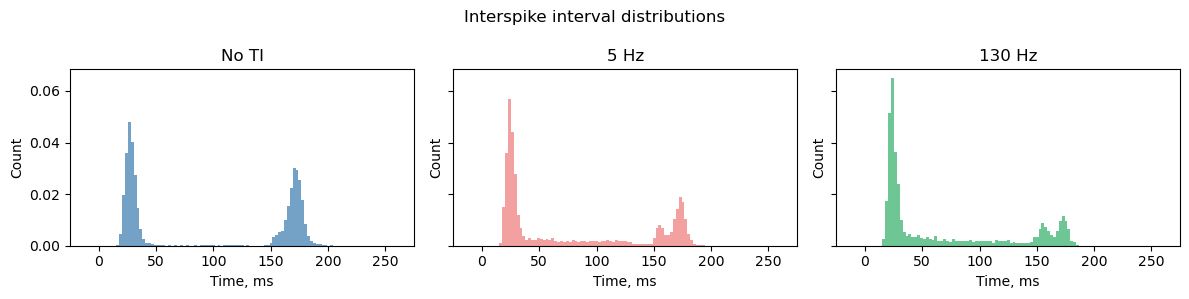

In [7]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3), sharey = True)

min = 0
max = 250

bin_edges = np.linspace(min, max, num = 100)

for i, label in enumerate(file_labels.keys()):
    isi = interspike_intervals[label]

    axs[i].hist(isi, bins = bin_edges, density = True, alpha = 0.75, label = label, color = colors[label])

    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Count")
    axs[i].set_title(label)
    axs[i].set_xlim(min - max * 0.1, max * 1.1)

fig.suptitle("Interspike interval distributions")
fig.tight_layout()
plt.show()

In [8]:
final_synaptic_weights = {
    "No TI": [ pd.read_csv(f"{output_dir}/{idx}/{file_labels['No TI']}/synapse_weights.csv").iloc[-1][2:] for idx in idxs ],
    "5 Hz": [ pd.read_csv(f"{output_dir}/{idx}/{file_labels['5 Hz']}/synapse_weights.csv").iloc[-1][2:] for idx in idxs ],
    "130 Hz": [ pd.read_csv(f"{output_dir}/{idx}/{file_labels['130 Hz']}/synapse_weights.csv").iloc[-1][2:] for idx in idxs ]
}

final_synaptic_weights["No TI"] = np.array(list(itertools.chain.from_iterable(final_synaptic_weights["No TI"])))
final_synaptic_weights["5 Hz"] = np.array(list(itertools.chain.from_iterable(final_synaptic_weights["5 Hz"])))
final_synaptic_weights["130 Hz"] = np.array(list(itertools.chain.from_iterable(final_synaptic_weights["130 Hz"])))

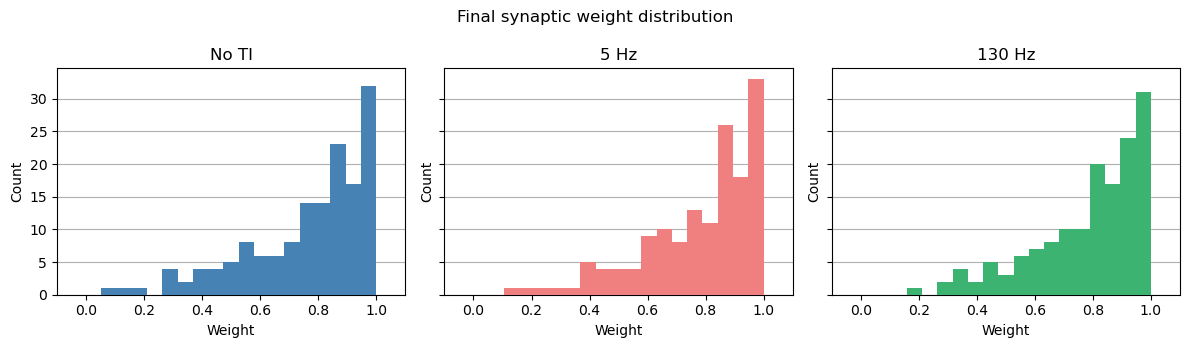

In [9]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3.5), sharey = True)

bin_edges = np.linspace(0, 1, num = 20)

for i, label in enumerate(file_labels.keys()):
    synapse_weights = final_synaptic_weights[label]

    axs[i].grid(axis = "y", zorder = 0)
    axs[i].hist(synapse_weights, color = colors[label], zorder = 3, bins = bin_edges)
    axs[i].set_title(label)
    axs[i].set_xlabel("Weight")
    axs[i].set_ylabel("Count")
    axs[i].set_xlim(-0.1, 1.1)

fig.suptitle("Final synaptic weight distribution")
fig.tight_layout()
plt.show()